This tutorial notebook will cover computing influence scores for the ResNet-9 & CIFAR-10 pipeline using Kronfluence. The notebook is inspired by the [TRAK repository](https://github.com/MadryLab/trak/blob/main/examples/cifar_quickstart.ipynb). We ran this notebook on an A100 GPU using Google Colab. Depending on your setup, you may need to reduce the batch sizes for training and computing influence scores. To begin, let's install the Kronfluence package.

We will import necessary packages for this tutorial.

In [1]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 4
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Device 1: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Device 2: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Device 3: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import os
from pathlib import Path
import sys
print("Current working directory:", os.getcwd())
sys.path.append("kronfluence")


import numpy as np
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
import torch.nn.functional as F
import torchvision
from scipy.stats import spearmanr
from matplotlib import pyplot as plt
from torch.nn import BatchNorm2d, Conv2d
from torch.optim import SGD, lr_scheduler
from tqdm.auto import tqdm

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

Current working directory: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion
True
4


/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Train Model and Save Checkpoints

We define the model architecture and the datasets.

In [3]:
class Mul(torch.nn.Module):
    def __init__(self, weight):
        super(Mul, self).__init__()
        self.weight = weight
    def forward(self, x):
        return x * self.weight


class Flatten(torch.nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)


class Residual(torch.nn.Module):
    def __init__(self, module):
        super(Residual, self).__init__()
        self.module = module

    def forward(self, x):
        return x + self.module(x)


def construct_rn9(num_classes=10):
    def conv_bn(channels_in, channels_out, kernel_size=3, stride=1, padding=1, groups=1):
        return torch.nn.Sequential(
                torch.nn.Conv2d(channels_in, channels_out, kernel_size=kernel_size,
                            stride=stride, padding=padding, groups=groups, bias=False),
                torch.nn.BatchNorm2d(channels_out),
                torch.nn.ReLU()
        )
    model = torch.nn.Sequential(
        conv_bn(3, 64, kernel_size=3, stride=1, padding=1),
        conv_bn(64, 128, kernel_size=5, stride=2, padding=2),
        Residual(torch.nn.Sequential(conv_bn(128, 128), conv_bn(128, 128))),
        conv_bn(128, 256, kernel_size=3, stride=1, padding=1),
        torch.nn.MaxPool2d(2),
        Residual(torch.nn.Sequential(conv_bn(256, 256), conv_bn(256, 256))),
        conv_bn(256, 128, kernel_size=3, stride=1, padding=0),
        torch.nn.AdaptiveMaxPool2d((1, 1)),
        Flatten(),
        torch.nn.Linear(128, num_classes, bias=False),
        Mul(0.2)
    )
    return model

In [4]:
def get_dataset(split="train", augment=True):
    # Augmentation configurations from:
    # https://github.com/mosaicml/composer/blob/d952e1da11256c430a8291cd39d57783d414b391/composer/datasets/cifar.py.
    if augment:
        transforms = torchvision.transforms.Compose(
                        [torchvision.transforms.RandomCrop(32, padding=4),
                         torchvision.transforms.RandomHorizontalFlip(),
                         torchvision.transforms.ToTensor(),
                         torchvision.transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                          (0.247, 0.243, 0.261))])
    else:
        transforms = torchvision.transforms.Compose([
                         torchvision.transforms.ToTensor(),
                         torchvision.transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                          (0.247, 0.243, 0.261))])

    is_train = (split == "train")
    dataset = torchvision.datasets.CIFAR10(root="/tmp/cifar/",
                                           download=True,
                                           train=is_train,
                                           transform=transforms)
    return dataset

After defining the model and dataset, we will now train ResNet-9 for 25 epochs. The training configurations are ported from [this paper](https://arxiv.org/abs/2405.12186).

In [5]:
def train(model, loader, lr=0.4, epochs=25, momentum=0.9,
          weight_decay=0.001, lr_peak_epoch=5, model_id=0):
    optimizer = SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    # Cyclic LR with single triangle.
    iters_per_epoch = len(loader)
    lr_schedule = np.interp(np.arange((epochs+1) * iters_per_epoch),
                            [0, lr_peak_epoch * iters_per_epoch, epochs * iters_per_epoch],
                            [0, 1, 0])
    scheduler = lr_scheduler.LambdaLR(optimizer, lr_schedule.__getitem__)

    for epoch in range(epochs):
        for it, (images, labels) in enumerate(loader):
            images = images.cuda()
            labels = labels.cuda()
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

        if epoch > 20:
            torch.save(model.state_dict(), f"./checkpoints/sd_{model_id}_epoch_{epoch}.pt")

    return model

In [6]:
os.makedirs("./checkpoints", exist_ok=True)
train_dataset = get_dataset(split="train", augment=True)
loader_for_training =  torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)

for i in tqdm(range(1), desc="Training models"):
    model = construct_rn9().cuda()
    model = train(model, loader_for_training, model_id=i)

100%|██████████| 170M/170M [00:06<00:00, 28.1MB/s] 
Training models: 100%|██████████| 1/1 [04:41<00:00, 281.96s/it]


All checkpoints are stored in the path `./checkpoints`.

In [7]:
ckpt_files = sorted(list(Path("./checkpoints").rglob("*.pt")))
ckpts = [torch.load(ckpt, map_location="cpu") for ckpt in ckpt_files]

## Check Final Validation Accuracy

After training the model, we can check the final validation accuracy.

In [8]:
model = construct_rn9().cuda()
model.load_state_dict(ckpts[-1])
model = model.eval()

In [9]:
valid_dataset = get_dataset(split="valid", augment=False)
loader = torch.utils.data.DataLoader(valid_dataset, batch_size=1024, shuffle=False, drop_last=False)

with torch.no_grad():
    total_correct, total_num = 0., 0.
    for images, labels in tqdm(loader):
        images = images.cuda()
        labels = labels.cuda()
        outputs = model(images)
        total_correct += outputs.argmax(1).eq(labels).sum().cpu().item()
        total_num += images.shape[0]

    print(f"Accuracy: {total_correct / total_num * 100:.1f}%")

100%|██████████| 10/10 [00:01<00:00,  7.37it/s]

Accuracy: 93.1%


The validation accuracy should be above 90%.

## Setting up Kronfluence

Now, let's compute influence scores using Kronfluence. We first need to write a `Task` class.

In [10]:
class ClassificationTask(Task):
    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()

Next, we will set up the `Analyzer` class and compute influence scores using the EKFAC factors.

In [11]:
# Prepare the model.
model = construct_rn9().cuda()
model.load_state_dict(ckpts[-1])
model = model.eval()
task = ClassificationTask()
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="cifar10",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_dataset,
    per_device_batch_size=2048,
    overwrite_output_dir=False,
)

# Use the non-augmented version of the training dataset for influence score computations.
eval_train_dataset = get_dataset(split="train", augment=False)

# Compute pairwise influence scores.
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=valid_dataset,
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=500,
    overwrite_output_dir=False,
)

/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [25/25] 100%|██████████ [time left: 00:00, time spent: 00:09]
Performing Eigendecomposition [9/9] 100%|██████████ [time left: 00:00, time spent: 00:00]
/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [25/25] 100%|██████████ [time left: 00:00, time spent: 00:15]
/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradSca

You can now load the score with `load_pairwise_scores`.

In [12]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
scores.shape

torch.Size([10000, 50000])

## [Optional] Influence Computations with Other Strategies

Instead of `ekfac`, we can use `identity`, `diagonal`, and `kfac` to compute influence scores. This step is optional and you can skip this part!

In [13]:
%%capture
strategies = ["identity", "diagonal", "kfac"]

for strategy in strategies:
    # Prepare the model.
    model = construct_rn9().cuda()
    model.load_state_dict(ckpts[-1])
    model = model.eval()
    task = ClassificationTask()
    model = prepare_model(model, task)

    # Fit all factors.
    analyzer.fit_all_factors(
        factors_name=strategy,
        dataset=train_dataset,
        factor_args=FactorArguments(strategy=strategy),
        per_device_batch_size=2048,
        overwrite_output_dir=False,
    )

    # Compute pairwise influence scores.
    analyzer.compute_pairwise_scores(
        scores_name=f"{strategy}_scores",
        factors_name=strategy,
        query_dataset=valid_dataset,
        train_dataset=eval_train_dataset,
        per_device_query_batch_size=500,
        overwrite_output_dir=False,
    )

KeyboardInterrupt: 

## Visualizing Influence Training Images

Let's visualize the most positively influential data points for some queries.

In [14]:
ds_train = torchvision.datasets.CIFAR10(root="/tmp/cifar/", download=True, train=True)
ds_val = torchvision.datasets.CIFAR10(root="/tmp/cifar/", download=True, train=False)

In [15]:
val_indices = [0, 512, 1376, 6920, 8124]

In [16]:
def visualize(scores, descending=True):
    for i in val_indices:
        fig, axs = plt.subplots(ncols=7, figsize=(15, 3))
        fig.suptitle("Top Influential Training Images")

        axs[0].imshow(ds_val[i][0])
        axs[0].axis("off")
        axs[0].set_title("Query Image")
        axs[1].axis("off")

        top_idxs = scores[i].argsort(descending=descending)[:5]
        for ii, idx in enumerate(top_idxs):
            axs[ii + 2].imshow(ds_train[idx][0])
            axs[ii + 2].axis("off")

        fig.show()

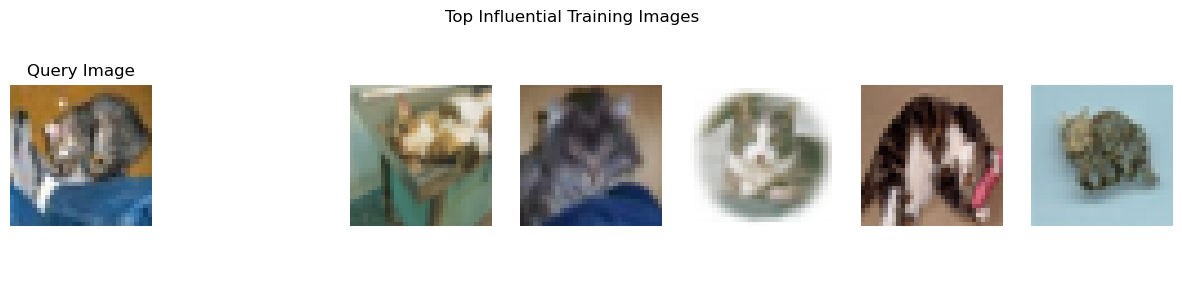

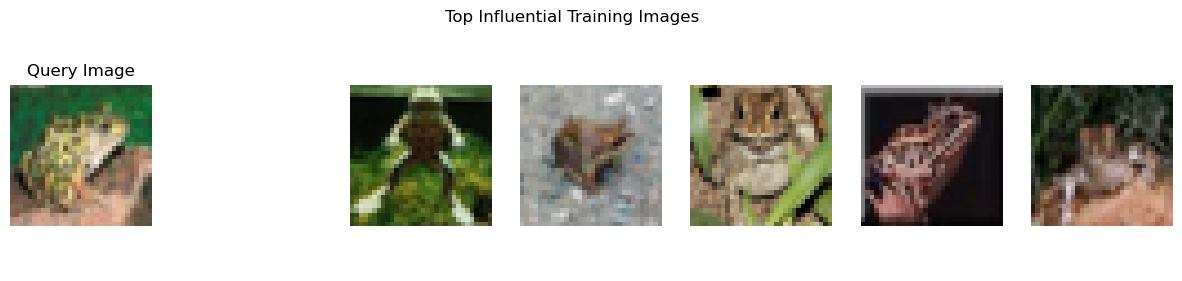

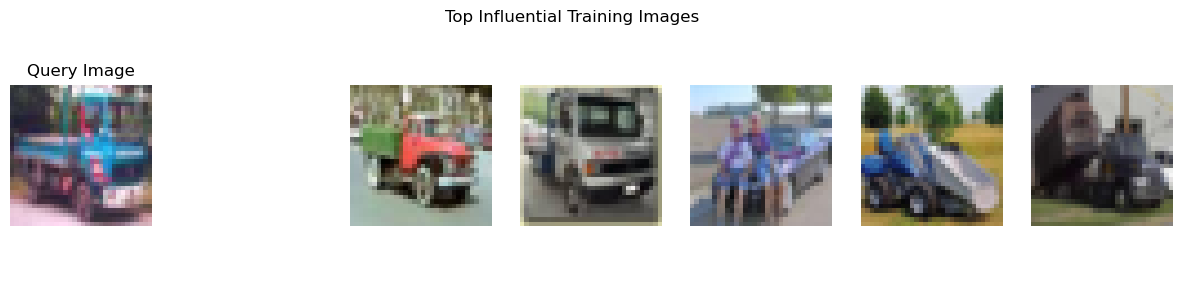

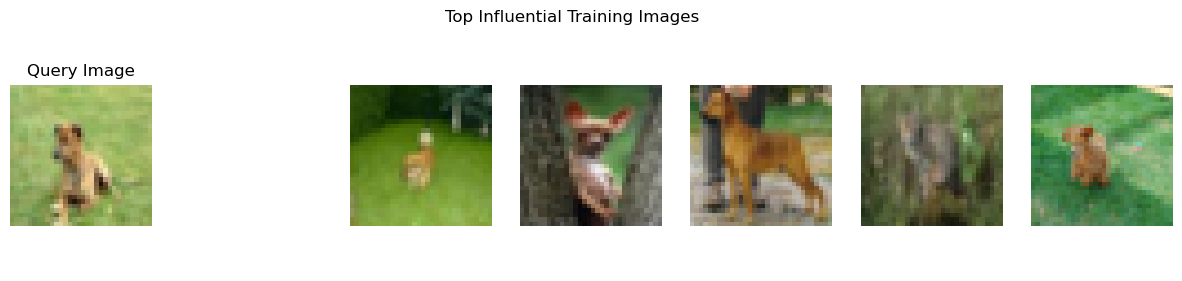

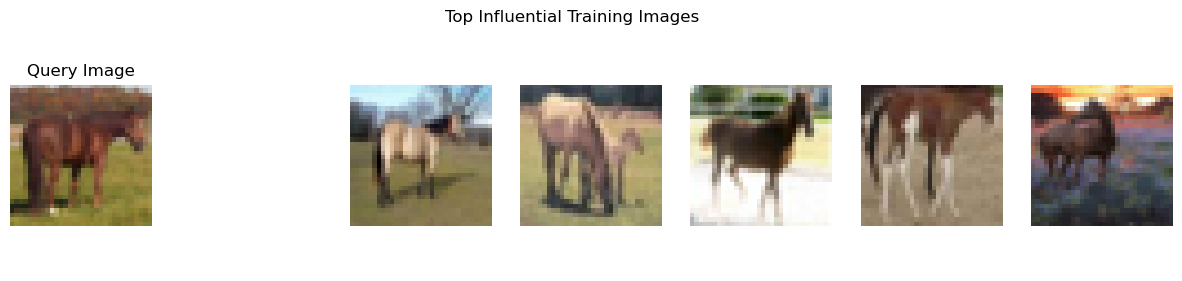

In [17]:
visualize(scores)

## Linear Datamodeling Score (LDS) Computations

We can further compute the [linear datamodeling score (LDS)](https://arxiv.org/abs/2303.14186) to evaluate the accuracy of influence estimates. We will first download the LDS groundtruth for 100 masks (50% of the dataset selected and 20 retrainings for each mask; in total of 2000 retrainings).

In [18]:
assert False

AssertionError: 

In [ ]:
gdown.download(
    "https://drive.google.com/uc?export=download&confirm=pbef&id=1fYehmfeD_xnK5q08HAFHocCYd7Ojlr4G",
    "margins.pt"
)

gdown.download(
    "https://drive.google.com/uc?export=download&confirm=pbef&id=1EVdrWewq3pv-i1nrsucVghz9vY13SC8u",
    "masks.pt"
)

Downloading...
From: https://drive.google.com/uc?export=download&confirm=pbef&id=1fYehmfeD_xnK5q08HAFHocCYd7Ojlr4G
To: /content/margins.pt
100%|██████████| 4.00M/4.00M [00:00<00:00, 219MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&confirm=pbef&id=1EVdrWewq3pv-i1nrsucVghz9vY13SC8u
To: /content/masks.pt
100%|██████████| 5.00M/5.00M [00:00<00:00, 20.1MB/s]


'masks.pt'

Then, we will compute the mean LDS for all validation data points.

In [ ]:
def evaluate_correlations(scores):
    margins = torch.load(open("margins.pt", "rb"))
    masks = torch.load(open("masks.pt", "rb")).float()

    val_indices = np.arange(10000)
    preds = masks @ scores.T

    rs = []
    ps = []
    for j in tqdm(val_indices):
        r, p = spearmanr(preds[:, j], margins[:, j])
        rs.append(r)
        ps.append(p)
    rs, ps = np.array(rs), np.array(ps)
    return rs.mean()

In [ ]:
evaluate_correlations(scores)

  0%|          | 0/10000 [00:00<?, ?it/s]

0.1307175333152386

If you have computed scores with other strategies, you can also check their LDS.

In [ ]:
evaluate_correlations(analyzer.load_pairwise_scores("identity_scores")["all_modules"])

  0%|          | 0/10000 [00:00<?, ?it/s]

0.03395375698569321

In [ ]:
evaluate_correlations(analyzer.load_pairwise_scores("diagonal_scores")["all_modules"])

  0%|          | 0/10000 [00:00<?, ?it/s]

0.03890426272549081

In [ ]:
evaluate_correlations(analyzer.load_pairwise_scores("kfac_scores")["all_modules"])

  0%|          | 0/10000 [00:00<?, ?it/s]

0.11565130283734812